## imports


In [36]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torchvision.datasets import ImageFolder
from torchvision import transforms
from sklearn.metrics import confusion_matrix, classification_report

print("successfully imported libraries")

successfully imported libraries


# Load Dataset

In [25]:
train_path = "../data/chest_xray/train"
test_path = "../data/chest_xray/test"

train_data = ImageFolder(train_path)
test_data = ImageFolder(test_path)

classes = train_data.classes
print("Classes:", classes)

Classes: ['NORMAL', 'PNEUMONIA']


# 1.Class Distribution

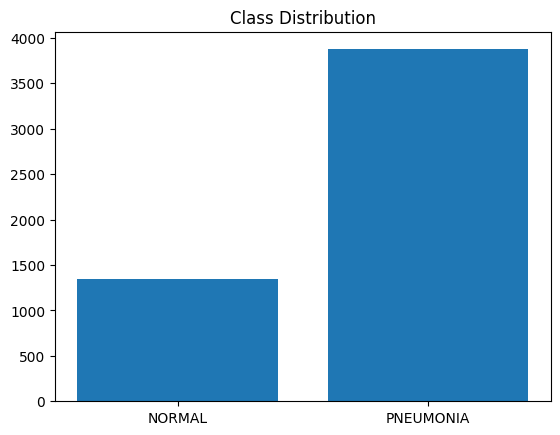

In [26]:
counts = [len(os.listdir(os.path.join(train_path, c))) for c in classes]

plt.figure()
plt.bar(classes, counts)
plt.title("Class Distribution")
plt.show()

# 2. Sample Images

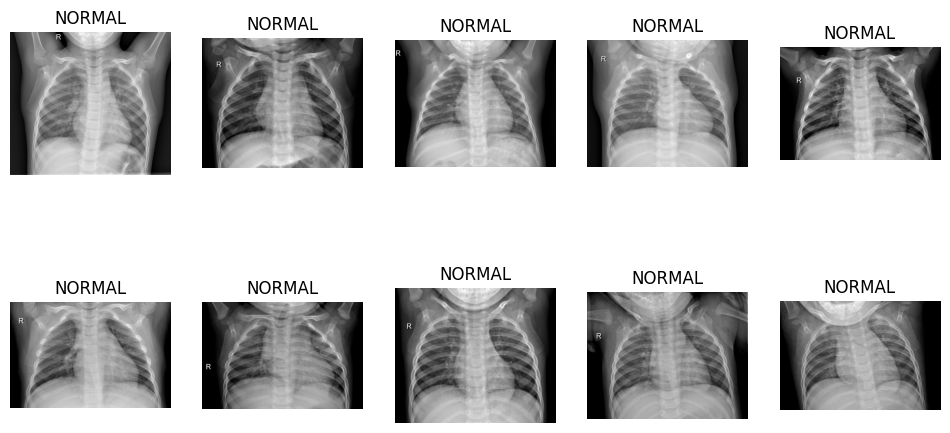

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img, cmap='gray')
    ax.set_title(classes[label])
    ax.axis('off')
plt.show()

# 3. Image Size Distribution

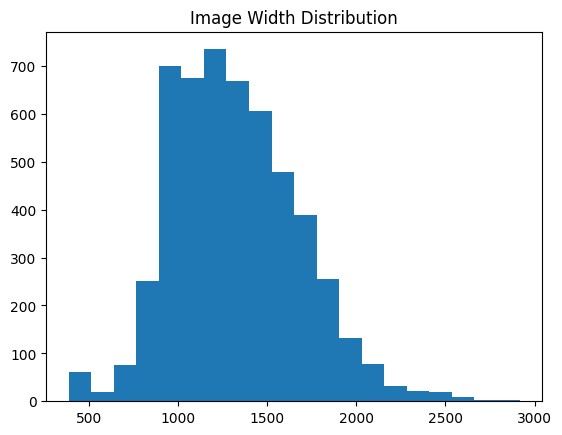

In [28]:
sizes = [img.size for img, _ in train_data]
widths = [s[0] for s in sizes]

plt.hist(widths, bins=20)
plt.title("Image Width Distribution")
plt.show()

# 4. Pixel Intensity Histogram

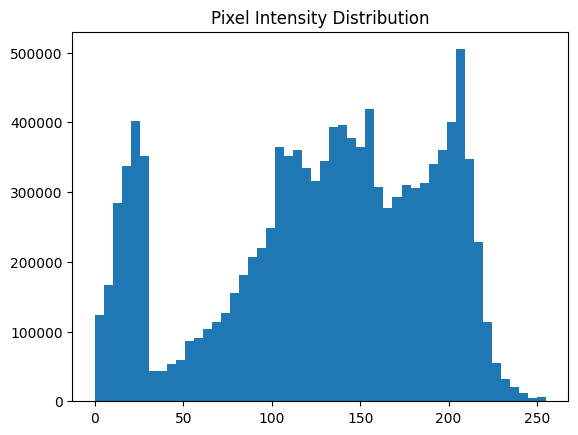

In [29]:
img, _ = train_data[0]
plt.hist(np.array(img).ravel(), bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

# 5. Class imbalance pie chart

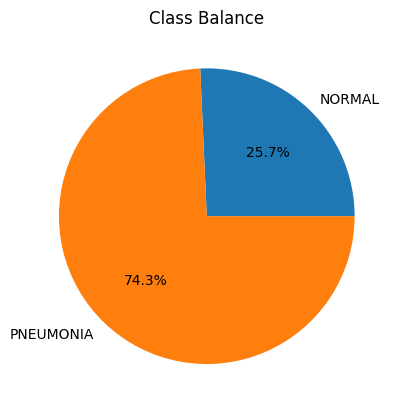

In [30]:
plt.pie(counts, labels=classes, autopct='%1.1f%%')
plt.title("Class Balance")
plt.show()

# 6. Augmented Samples

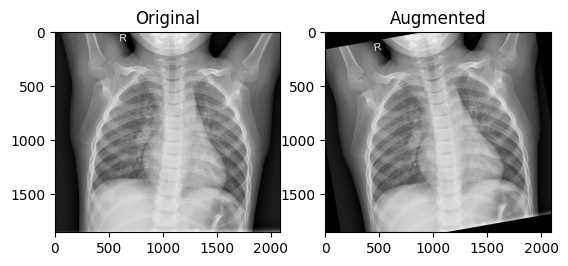

In [31]:
aug = transforms.RandomRotation(10)
img, _ = train_data[0]

fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original")
ax[1].imshow(aug(img), cmap='gray')
ax[1].set_title("Augmented")
plt.show()

# MODEL EVALUATION FUNCTION


In [32]:
def evaluate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred, target_names=classes))

# RUN MODEL PREDICTIONS

In [ ]:
import sys, torch
sys.path.insert(0, '../src')
from model import get_model
from dataset import get_test_loader

model = get_model()
model.load_state_dict(torch.load('../api/model.pth', map_location='cpu'))
model.eval()

test_loader = get_test_loader('../data/chest_xray')
print('Model and test_loader ready')

In [ ]:
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.numpy())

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>

In [ ]:
evaluate(y_true, y_pred)

# 7.Loss curve


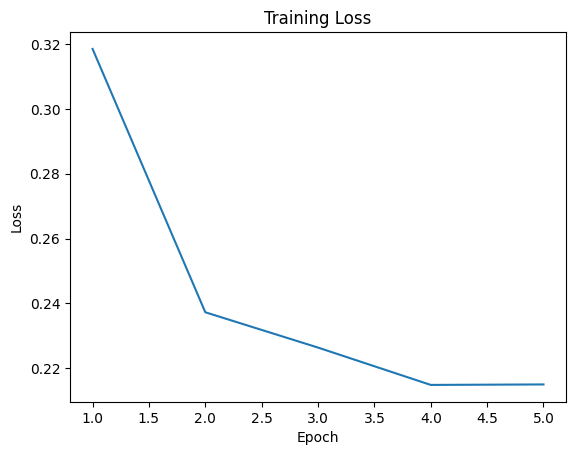

In [33]:
with open("../api/training_results.json") as f:
    data = json.load(f)

epochs = list(range(1, len(data["train_losses"]) + 1))

plt.figure()
plt.plot(epochs, data["train_losses"], label="Train Loss")
if "val_losses" in data:
    plt.plot(epochs, data["val_losses"], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# 8.recall curve

ValueError: x and y must have same first dimension, but have shapes (815,) and (5,)

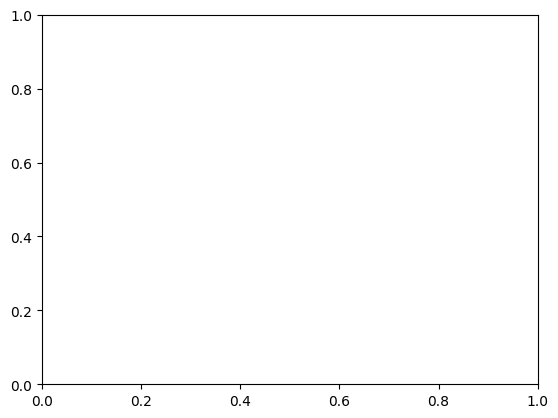

In [17]:
plt.plot(epochs, data["recalls"])
plt.title("Recall per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.show()

print("Best Epoch:", data["best_epoch"])
print("Final Recall:", data["final_recall"])

# confusion matrix + F1

In [34]:
def evaluate(y_true, y_pred, save_path="eval_results.json"):
    
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["NORMAL", "PNEUMONIA"],
                yticklabels=["NORMAL", "PNEUMONIA"])
    plt.title("Confusion Matrix")
    plt.show()

    report = classification_report(y_true, y_pred, output_dict=True)
    print(classification_report(y_true, y_pred))

    with open(save_path, "w") as f:
        json.dump({
            "confusion_matrix": cm.tolist(),
            "classification_report": report
        }, f, indent=4)

    print("Saved evaluation results")
